# Softmax Policy Sharpness Analysis
This notebook visualizes and analyzes the effects of softmax sharpness (1/τ) on policy behavior and gradient norms using Seaborn for plotting.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import seaborn as sns

# Set Seaborn style (dark background)
sns.set_style('darkgrid')
# Set the color palette to 'colorblind'
sns.set_palette('colorblind')

K = 100
A_hat = 1.0
h_norm = 1.0

In [4]:
def softmax_decay_policy(K, tau):
    indices = np.arange(K)
    logits = -indices / tau
    exp_logits = np.exp(logits - np.max(logits))
    return exp_logits / np.sum(exp_logits)

## 1. GIF of Softmax Policy Histograms at Varying Sharpness

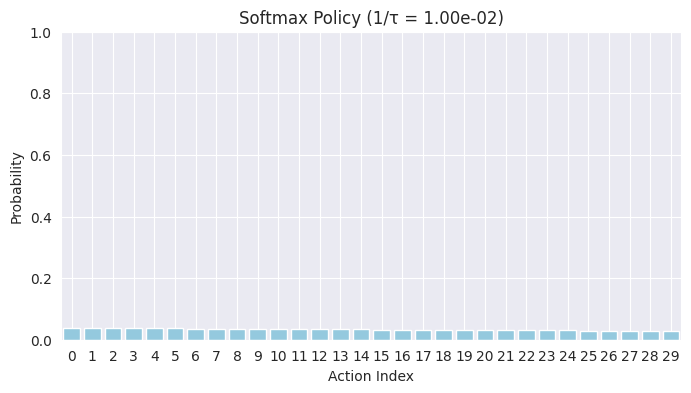

In [5]:
# Generate GIF of softmax histograms and static figure grid (8 frames)

K_gif = 30
inv_taus_gif = np.logspace(-2, 1, 15)
taus_gif = 1 / inv_taus_gif
policies_gif = [softmax_decay_policy(K_gif, tau) for tau in taus_gif]

# --- Animated GIF ---
fig, ax = plt.subplots(figsize=(8, 4))
def update(frame):
    ax.clear()
    tau = taus_gif[frame]
    inv_tau = inv_taus_gif[frame]
    pi = policies_gif[frame]
    sns.barplot(x=np.arange(len(pi)), y=pi, ax=ax, color='skyblue')
    ax.set_ylim(0, 1)
    ax.set_title(f"Softmax Policy (1/τ = {inv_tau:.2e})")
    ax.set_xlabel("Action Index")
    ax.set_ylabel("Probability")
    ax.grid(True)

ani = animation.FuncAnimation(fig, update, frames=len(taus_gif), interval=1000)
HTML(ani.to_jshtml())


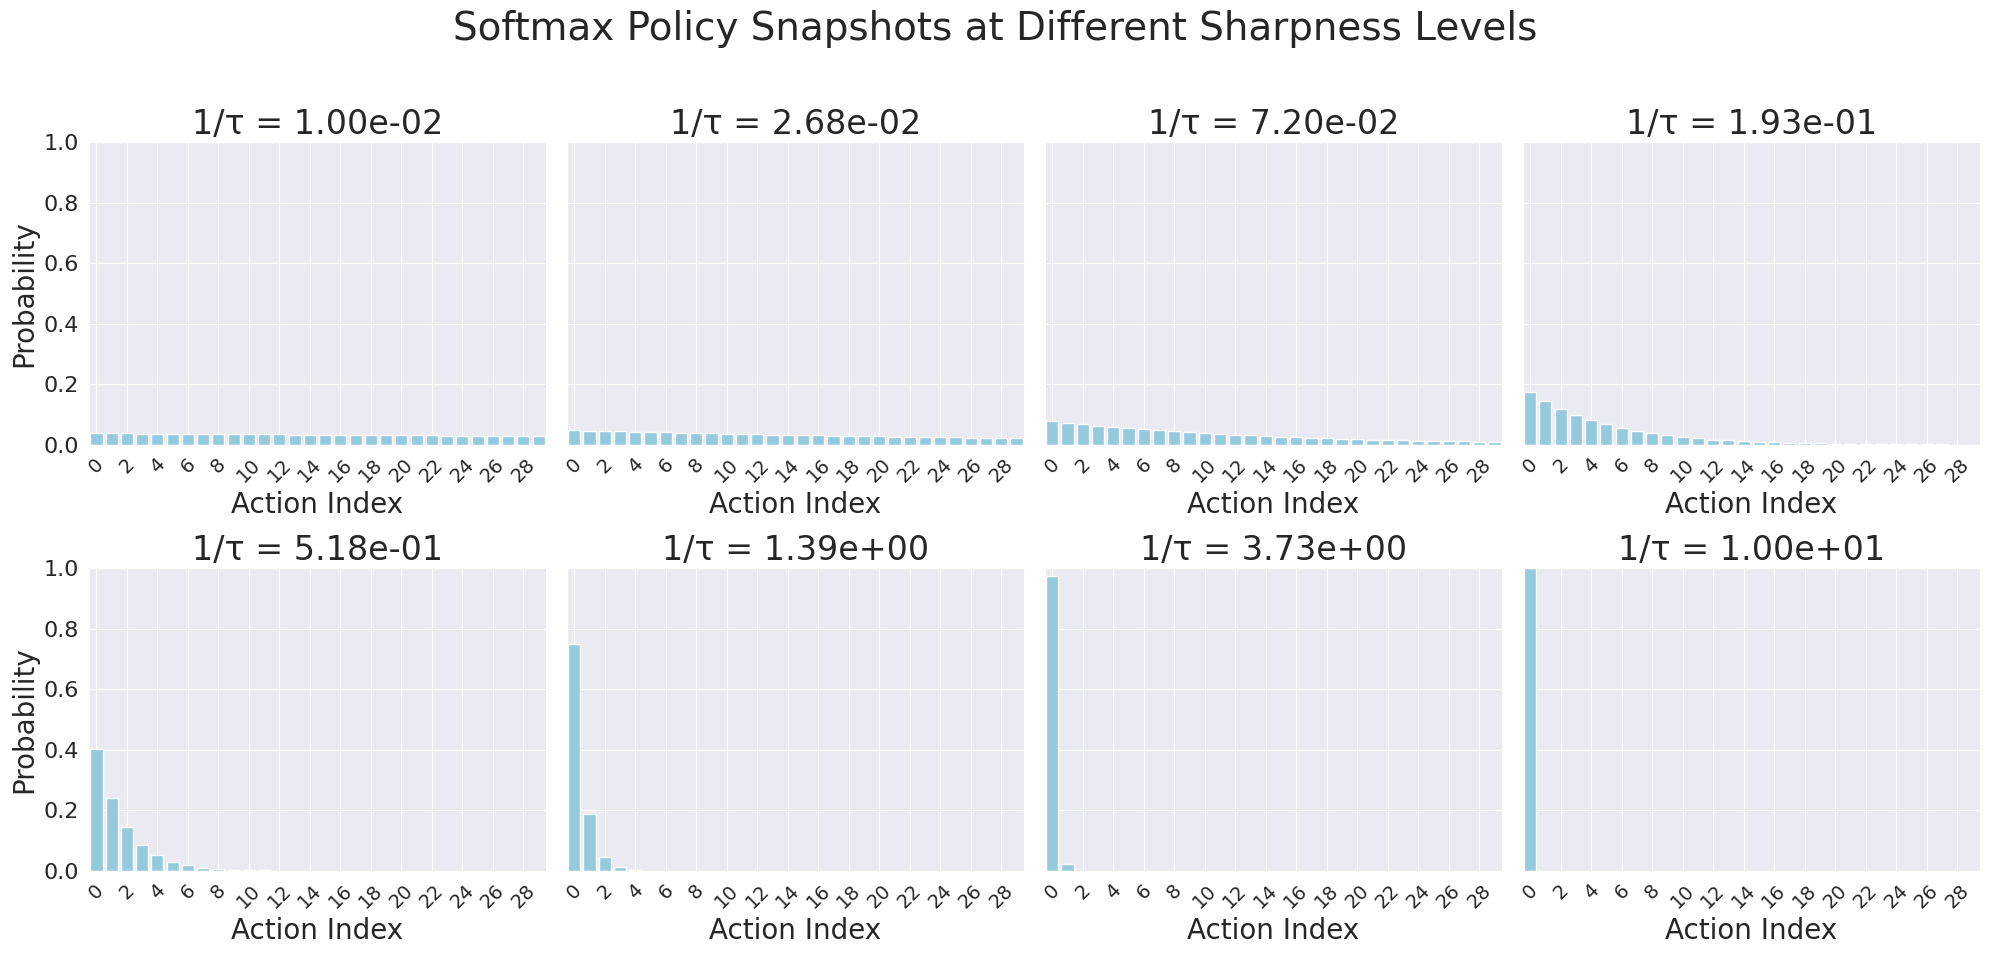

In [6]:
# --- Static Grid of 8 Snapshots (large fonts, sparse x-axis labels) ---
fig_grid, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True)
frame_indices = np.linspace(0, len(taus_gif) - 1, 8, dtype=int)

for ax, idx in zip(axes.flat, frame_indices):
    tau = taus_gif[idx]
    inv_tau = inv_taus_gif[idx]
    pi = policies_gif[idx]
    sns.barplot(x=np.arange(len(pi)), y=pi, ax=ax, color='skyblue')
    ax.set_title(f"1/τ = {inv_tau:.2e}", fontsize=24)
    ax.set_xlabel("Action Index", fontsize=20)
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(0, len(pi), 2))  # Show every other index
    ax.tick_params(axis='x', labelsize=14, rotation=45)
    ax.tick_params(axis='y', labelsize=16)
    ax.grid(True)

axes[0, 0].set_ylabel("Probability", fontsize=20)
axes[1, 0].set_ylabel("Probability", fontsize=20)
plt.suptitle("Softmax Policy Snapshots at Different Sharpness Levels", fontsize=28)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## 2. Gradient Norm vs. Sharpness for Fixed Action Probabilities

/scratch-ssd/lucelo/tmp/ipykernel_1392252/1544511274.py:10: RuntimeWarning: invalid value encountered in sqrt
  grad_norm = A_hat * np.sqrt((1 - 2 * p + pi_l2_sq)) * h_norm


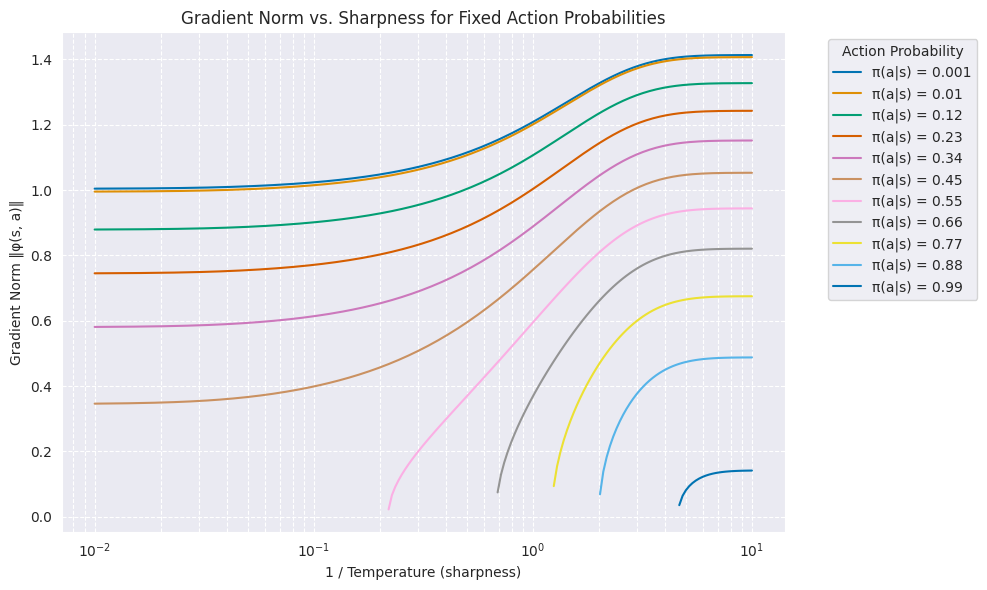

In [7]:
tracked_probs = np.append(0.001, np.linspace(0.01, 0.99, 10))
inv_taus = np.logspace(-2, 1, 200)
taus = 1 / inv_taus
grad_curves = {p: [] for p in tracked_probs}

for tau in taus:
    pi = softmax_decay_policy(K, tau)
    pi_l2_sq = np.sum(pi**2)
    for p in tracked_probs:
        grad_norm = A_hat * np.sqrt((1 - 2 * p + pi_l2_sq)) * h_norm
        grad_curves[p].append(grad_norm)

plt.figure(figsize=(10, 6))
for p in tracked_probs:
    label = f"π(a|s) = {p:.3f}" if p < 0.01 else f"π(a|s) = {p:.2f}"
    sns.lineplot(x=inv_taus, y=grad_curves[p], label=label)
plt.xscale("log")
plt.xlabel("1 / Temperature (sharpness)")
plt.ylabel("Gradient Norm ‖φ(s, a)‖")
plt.title("Gradient Norm vs. Sharpness for Fixed Action Probabilities")
plt.legend(title="Action Probability", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", linestyle="--")
plt.tight_layout()
plt.show()

## 3. Gradient Norm Variance vs. Sharpness (1/τ ∈ [10⁻², 10¹])

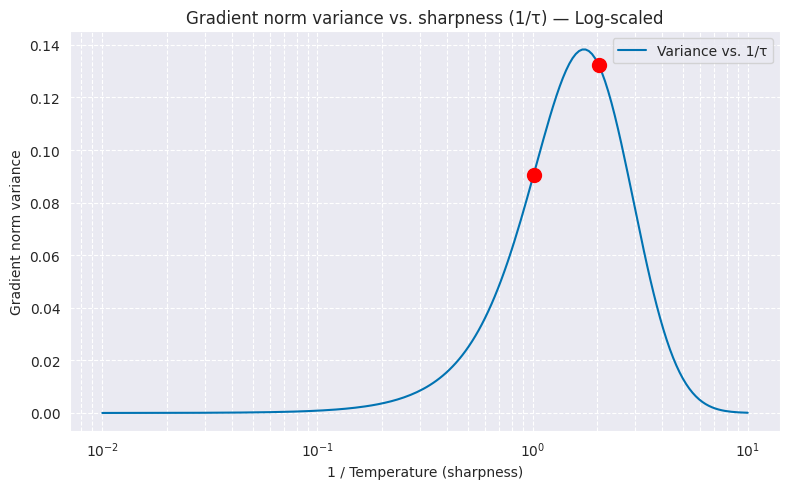

In [8]:
inv_taus_var = np.logspace(-2, 1, 200)
taus_var = 1 / inv_taus_var
variances = []

for tau in taus_var:
    pi = softmax_decay_policy(K, tau)
    pi_l2_sq = np.sum(pi**2)
    grad_norm_sq_all = [A_hat**2 * (1 - 2 * pi[a] + pi_l2_sq) * h_norm**2 for a in range(K)]
    expected_sq = np.sum(pi * grad_norm_sq_all)
    expected = np.sum(pi * np.sqrt(grad_norm_sq_all))
    variance = expected_sq - expected**2
    variances.append(variance)

plt.figure(figsize=(8, 5))
sns.lineplot(x=inv_taus_var, y=variances, label="Variance vs. 1/τ")

# Add red points at sharpness 1 and 2
point_idx_1 = np.abs(inv_taus_var - 1).argmin()
point_idx_2 = np.abs(inv_taus_var - 2).argmin()
plt.plot(inv_taus_var[point_idx_1], variances[point_idx_1], 'ro', markersize=10)
plt.plot(inv_taus_var[point_idx_2], variances[point_idx_2], 'ro', markersize=10)

plt.xscale("log")
plt.xlabel("1 / Temperature (sharpness)")
plt.ylabel("Gradient norm variance")
plt.title("Gradient norm variance vs. sharpness (1/τ) — Log-scaled")
plt.grid(True, which="both", linestyle="--")
plt.tight_layout()
plt.show()

## 4. Gradient Norm vs. Sharpness (1/τ ∈ [10⁻², 10¹]) - Softplus Transformation

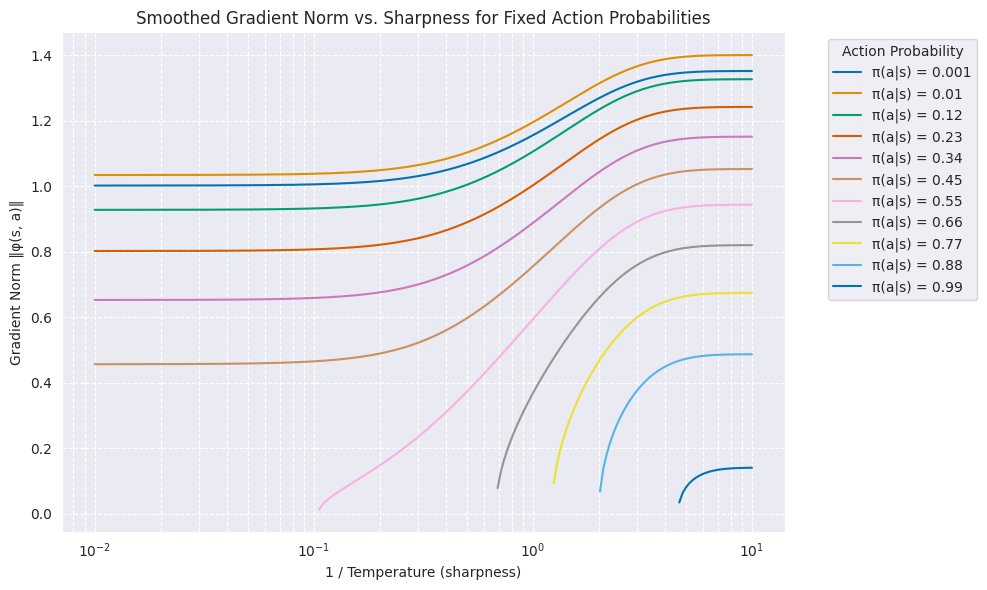

In [9]:
# Redefine softplus and sigmoid functions
def softplus(x):
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Parameters
K = 10
c = 10
tracked_probs = np.append(0.001, np.linspace(0.01, 0.99, 10))
inv_taus = np.logspace(-2, 1, 200)
taus = 1 / inv_taus
grad_curves = {p: [] for p in tracked_probs}
taus_assigned = {p: [] for p in tracked_probs}

for tau in taus:
    pi = softmax_decay_policy(K, tau)
    pi_l2_sq = np.sum(pi**2)
    # print(pi)
    for p in tracked_probs:
        if 1 - 2 * p + pi_l2_sq > 0:
            z = np.log(p)
            sig = sigmoid(z + c)
            grad_norm = A_hat * sig * np.sqrt(1 - 2 * p + pi_l2_sq) * h_norm
            grad_curves[p].append(grad_norm)
            taus_assigned[p].append(1 / tau)

# Plotting
plt.figure(figsize=(10, 6))
for p in tracked_probs:
    label = f"π(a|s) = {p:.3f}" if p < 0.01 else f"π(a|s) = {p:.2f}"
    plt.plot(taus_assigned[p], grad_curves[p], label=label)
plt.xscale("log")
plt.xlabel("1 / Temperature (sharpness)")
plt.ylabel("Gradient Norm ‖φ(s, a)‖")
plt.title("Smoothed Gradient Norm vs. Sharpness for Fixed Action Probabilities")
plt.legend(title="Action Probability", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", linestyle="--")
plt.tight_layout()
plt.show()

## 5. Gradient Norm Variance vs. Log_pi (1/τ ∈ [10⁻², 10¹]) - Softplus Transformation

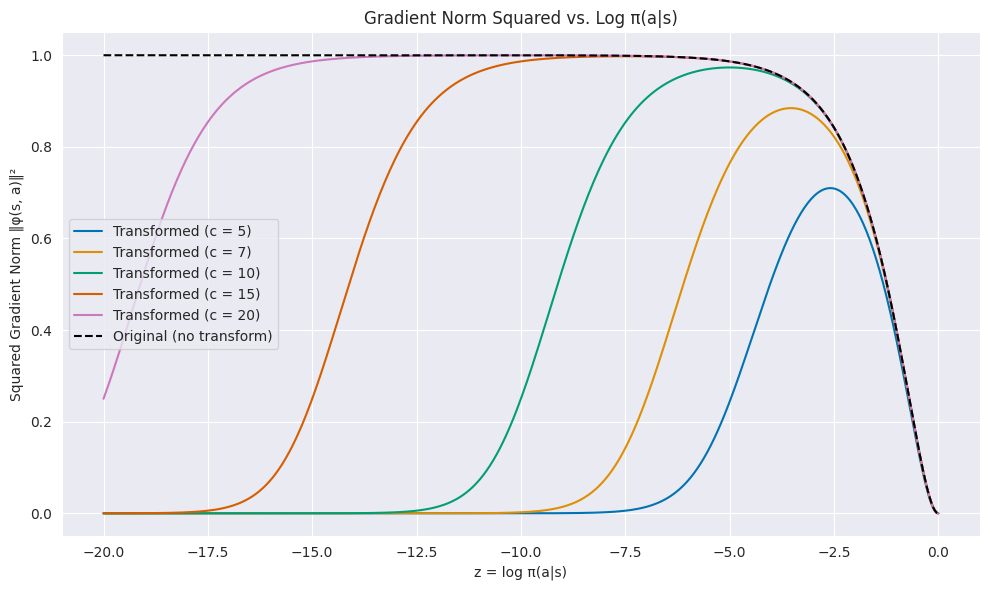

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Define softplus and sigmoid
def softplus(x):
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Hyperparameters
A_hat = 1.0
h_norm = 1.0
c_values = [5, 7, 10, 15, 20]

# Domain: log pi(a|s) ∈ (-∞, 0]
z_vals = np.linspace(-20, 0, 500)

# Store curves
gradient_norms = {}

# Compute transformed gradient norms
for c in c_values:
    sig = sigmoid(z_vals + c)
    pi_transformed = np.exp(softplus(z_vals + c) - c)
    grad_sq = A_hat**2 * sig**2 * (1 - pi_transformed)**2 * h_norm**2
    gradient_norms[f"Transformed (c = {c})"] = grad_sq

# Original REINFORCE (no transform)
pi_original = np.exp(z_vals)
grad_original_sq = A_hat**2 * (1 - pi_original)**2 * h_norm**2
gradient_norms["Original (no transform)"] = grad_original_sq

# Plotting
plt.figure(figsize=(10, 6))
for label, values in gradient_norms.items():
    linestyle = '--' if "Original" in label else '-'
    color = 'black' if "Original" in label else None
    plt.plot(z_vals, values, label=label, linestyle=linestyle, color=color)

plt.xlabel("z = log π(a|s)")
plt.ylabel("Squared Gradient Norm ‖φ(s, a)‖²")
plt.title("Gradient Norm Squared vs. Log π(a|s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


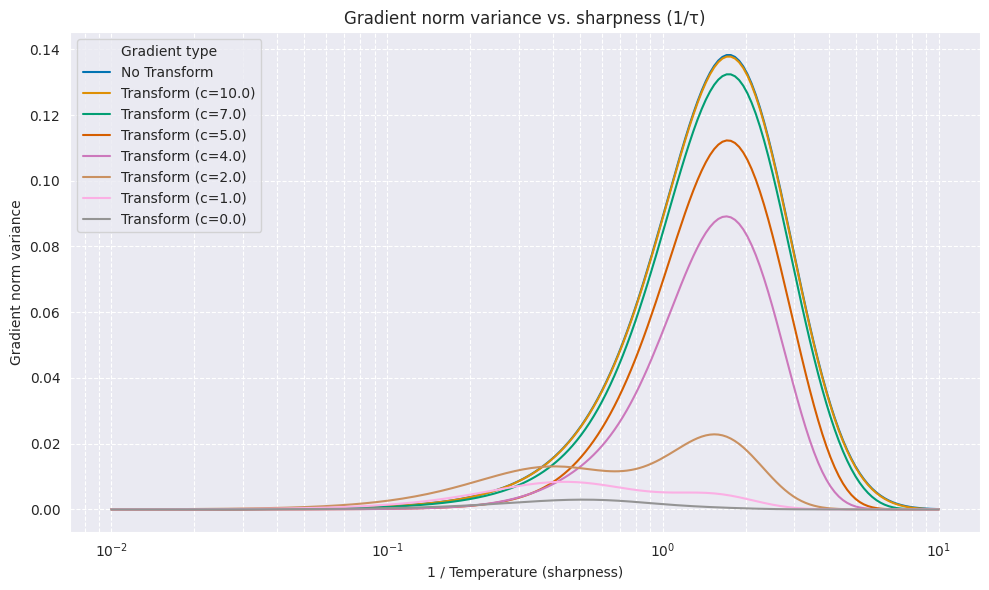

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax, expit  # expit is sigmoid

# Parameters
K = 10  # number of actions
A_hat = 1.0
h_norm = 1.0
c_values = [0.0, 1.0, 2.0, 4.0, 5.0, 7.0, 10.0]  # values for softplus shift
inv_taus_var = np.logspace(-2, 1, 200)
taus_var = 1 / inv_taus_var

def softmax_decay_policy(K, tau):
    logits = -np.arange(K) / tau  # increasingly negative logits
    return softmax(logits)

# Store results
results = {}

# Vanilla (no transformation)
vanilla_variances = []
for tau in taus_var:
    pi = softmax_decay_policy(K, tau)
    pi_l2_sq = np.sum(pi**2)
    grad_norm_sq_all = [A_hat**2 * (1 - 2 * pi[a] + pi_l2_sq) * h_norm**2 for a in range(K)]
    expected_sq = np.sum(pi * grad_norm_sq_all)
    expected = np.sum(pi * np.sqrt(grad_norm_sq_all))
    variance = expected_sq - expected**2
    vanilla_variances.append(variance)
results["No Transform"] = vanilla_variances

# With softplus-based damping
for c in reversed(c_values):
    variances = []
    for tau in taus_var:
        pi = softmax_decay_policy(K, tau)
        pi_l2_sq = np.sum(pi ** 2)
        grad_norm_sq_all = []

        for a in range(K):
            log_pi_a = np.log(pi[a])
            damping = expit(log_pi_a + c) ** 2
            base = (1 - 2 * pi[a] + pi_l2_sq)
            norm_sq = A_hat ** 2 * damping * base * h_norm ** 2
            grad_norm_sq_all.append(norm_sq)

        expected_sq = np.sum(pi * grad_norm_sq_all)
        expected = np.sum(pi * np.sqrt(grad_norm_sq_all))
        variance = expected_sq - expected ** 2
        variances.append(variance)

    results[f"Transform (c={c})"] = variances

# Plotting
plt.figure(figsize=(10, 6))
for label, var in results.items():
    sns.lineplot(x=inv_taus_var, y=var, label=label)

plt.xscale("log")
plt.xlabel("1 / Temperature (sharpness)")
plt.ylabel("Gradient norm variance")
plt.title("Gradient norm variance vs. sharpness (1/τ)")
plt.grid(True, which="both", linestyle="--")
plt.legend(title="Gradient type")
plt.tight_layout()
plt.show()


## 5. Gradient Norm Variance vs. Sharpness (1/τ ∈ [10⁻², 10¹]) - Softplus Transformation

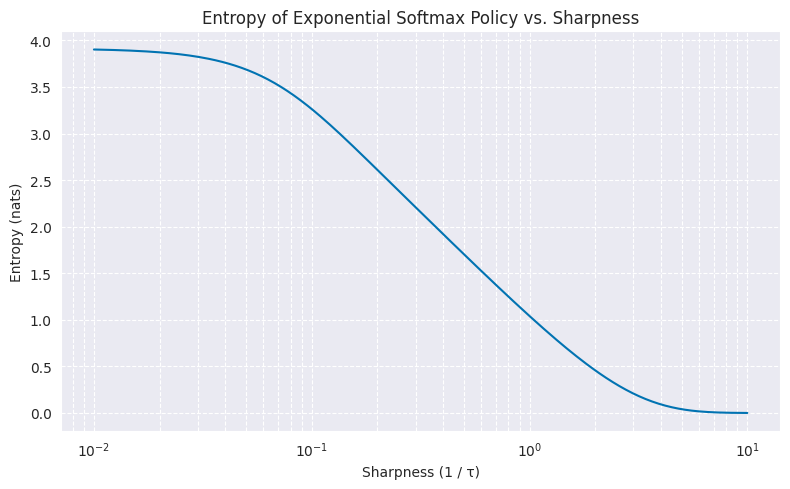

In [12]:
import torch
import matplotlib.pyplot as plt

def entropy_from_sharpness(sharpness: float, num_actions: int) -> float:
    indices = torch.arange(num_actions, dtype=torch.float32)
    logits = -sharpness * indices
    pi = torch.softmax(logits, dim=0)
    entropy = -(pi * torch.log(pi + 1e-12)).sum()
    return entropy.item()

# Define sharpness values
sharpness_values = torch.logspace(-2, 1, steps=200)  # from 0.01 to 10
entropy_values = [entropy_from_sharpness(s.item(), num_actions=50) for s in sharpness_values]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(sharpness_values, entropy_values)
plt.xscale("log")
plt.xlabel("Sharpness (1 / τ)")
plt.ylabel("Entropy (nats)")
plt.title("Entropy of Exponential Softmax Policy vs. Sharpness")
plt.grid(True, which="both", linestyle="--")
plt.tight_layout()
plt.show()


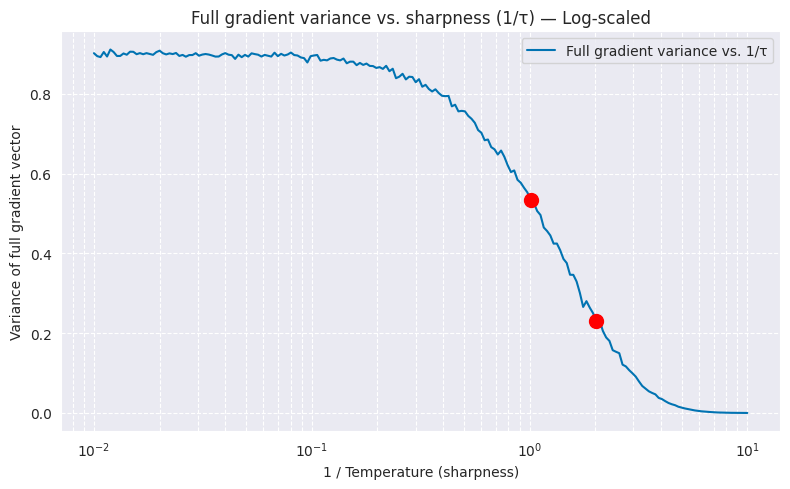

In [13]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters
K = 10        # Number of actions
D = 1000      # Feature dimension
h_norm = 1.0
A_hat = 1.0   # Scalar advantage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def softmax_decay_policy(K, tau):
    indices = torch.arange(K, device=device)
    logits = -indices.float() / tau
    return torch.softmax(logits, dim=0)  # shape (K,)

inv_taus_var = torch.logspace(-2, 1, 200, device=device)
taus_var = 1 / inv_taus_var
variances_fullgrad = []

for tau in taus_var:
    pi = softmax_decay_policy(K, tau)  # shape (K,)

    # One-hot actions: shape (K, K)
    one_hot_actions = torch.eye(K, device=device)

    # (e_a - pi): shape (K, K)
    delta = one_hot_actions - pi.unsqueeze(0)  # subtract π from each row

    # Advantage: shape (K,)
    advantages = torch.full((K,), A_hat, device=device)

    # Weighted deltas: shape (K, K)
    weighted_delta = advantages.unsqueeze(1) * delta

    # Feature vectors for each action: H ∈ ℝ^{K × D}
    H = torch.randn(K, D, device=device)
    H = H / H.norm(dim=1, keepdim=True) * h_norm  # normalize to h_norm

    # Now compute: grad_a = weighted_delta[a] @ H → (K, D)
    gradients = weighted_delta @ H  # shape: (K, D)

    # Mean gradient
    mean_grad = (pi.unsqueeze(1) * gradients).sum(dim=0)  # shape (D,)

    # Variance = E[‖∇_a − E[∇]‖²]
    squared_diff = (gradients - mean_grad.unsqueeze(0)).pow(2).sum(dim=1)  # shape (K,)
    variance = (pi * squared_diff).sum().item()
    variances_fullgrad.append(variance)

# Plotting
plt.figure(figsize=(8, 5))
sns.lineplot(x=inv_taus_var.cpu().numpy(), y=variances_fullgrad, label="Full gradient variance vs. 1/τ")

# Red dots at 1 and 2
inv_taus_np = inv_taus_var.cpu().numpy()
point_idx_1 = (torch.abs(inv_taus_var - 1)).argmin().item()
point_idx_2 = (torch.abs(inv_taus_var - 2)).argmin().item()
plt.plot(inv_taus_np[point_idx_1], variances_fullgrad[point_idx_1], 'ro', markersize=10)
plt.plot(inv_taus_np[point_idx_2], variances_fullgrad[point_idx_2], 'ro', markersize=10)

plt.xscale("log")
plt.xlabel("1 / Temperature (sharpness)")
plt.ylabel("Variance of full gradient vector")
plt.title("Full gradient variance vs. sharpness (1/τ) — Log-scaled")
plt.grid(True, which="both", linestyle="--")
plt.tight_layout()
plt.show()


## 6. Hessian Curvature - Policy Sharpness

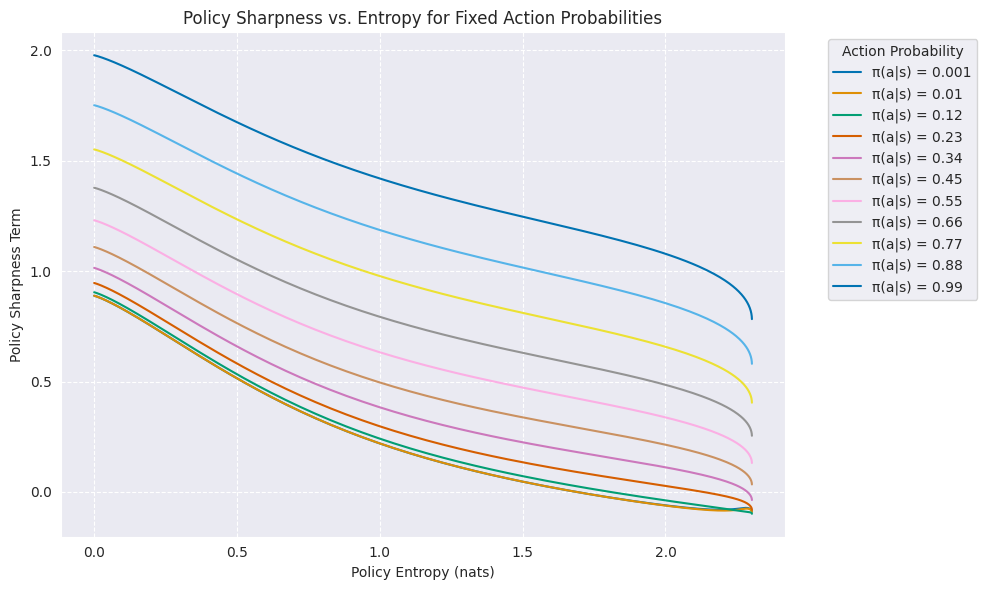

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax
from scipy.stats import entropy

# Configuration
K = 10  # number of actions
tracked_probs = np.append(0.001, np.linspace(0.01, 0.99, 10))
inv_taus_extended = np.logspace(-2, 2, 300)  # wide range of inverse temperatures
taus_extended = 1 / inv_taus_extended

# Fixed deterministic logits for reproducibility
def softmax_decay_policy_fixed(K, tau):
    logits = np.linspace(-1, 1, K)  # evenly spaced logits
    return softmax(logits / tau)

# Compute the sharpness term: ||v||^2 - vᵀ F v / ||v||^2
def compute_policy_sharpness(pi, pa):
    v = pa - pi
    v_norm_sq = np.sum(v ** 2)
    fisher = sum([
        pi[i] * np.outer((np.eye(K)[i] - pi), (np.eye(K)[i] - pi)) for i in range(K)
    ])
    fisher_term = v @ fisher @ v
    return v_norm_sq - fisher_term / v_norm_sq

# Storage
sharpness_curves_entropy_extended = {p: [] for p in tracked_probs}
entropy_values_extended = []

# Main loop
for tau in taus_extended:
    pi = softmax_decay_policy_fixed(K, tau)
    ent = entropy(pi, base=np.e)  # in nats
    entropy_values_extended.append(ent)
    for p in tracked_probs:
        pa = np.zeros(K)
        pa[0] = p
        pa[1:] = (1 - p) / (K - 1)
        sharpness = compute_policy_sharpness(pi, pa)
        sharpness_curves_entropy_extended[p].append(sharpness)

# Sort by entropy for smooth curves
entropy_values_extended = np.array(entropy_values_extended)
sorted_indices_ext = np.argsort(entropy_values_extended)
sorted_entropy_ext = entropy_values_extended[sorted_indices_ext]

# Plotting
plt.figure(figsize=(10, 6))
for p in tracked_probs:
    sorted_sharpness = np.array(sharpness_curves_entropy_extended[p])[sorted_indices_ext]
    label = f"π(a|s) = {p:.3f}" if p < 0.01 else f"π(a|s) = {p:.2f}"
    sns.lineplot(x=sorted_entropy_ext, y=sorted_sharpness, label=label)
plt.xlabel("Policy Entropy (nats)")
plt.ylabel("Policy Sharpness Term")
plt.title("Policy Sharpness vs. Entropy for Fixed Action Probabilities")
plt.legend(title="Action Probability", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", linestyle="--")
plt.tight_layout()
plt.show()
